# SKAB — Isolation Forest vs. Mahalanobis Distance

Module 3 benchmarked Univariate Z-Score against Mahalanobis Distance across all SKAB experiments and found the two methods performed similarly — SKAB anomalies are typically large single-sensor spikes that both methods catch with comparable F1.

This notebook asks: does Isolation Forest change that picture? IF makes no distributional assumptions and implicitly models feature interactions via random tree splits. On SKAB's 8-sensor industrial testbed, it should at minimum match Mahalanobis — and potentially outperform on the `other` experiments (cavitation, rotor imbalance, fluid leaks) where anomalies may be nonlinear.

## Setup

- **Training:** first 400 rows of each file (normal operation only) — matching Module 3
- **Evaluation:** full file (train + anomaly window) against the `anomaly` column
- **Features:** 8 sensors (same as Module 3; SKAB has no binary actuators)
- **IF hyperparameters:** `n_estimators=200`, `contamination='auto'`, `random_state=42`

**On `contamination='auto'`:** Rather than specifying a fixed anomaly rate estimate, `'auto'` uses the theoretical threshold from Liu et al. (2008) — the score midpoint of −0.5, below which points are considered anomalies. This is the closest IF equivalent to Mahalanobis's principled chi-squared threshold: both are derived from the algorithm's mathematical properties rather than requiring an empirical anomaly rate estimate. No scaling is applied; tree-based splits are invariant to monotonic feature transformations.

**Note on comparison fairness:** Module 3 Mahalanobis results are recomputed here in the same benchmark loop for a clean side-by-side. Numbers match the Module 3 notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
features = [
    'Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
    'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS'
]
TRAIN_ROWS = 400
p = len(features)
chi2_threshold = chi2.ppf(0.999, df=p)
IF_CONTAMINATION = 'auto'

print(f'Features: {p}')
print(f'Mahalanobis chi-squared threshold (99.9%, df={p}): {chi2_threshold:.4f}')
print(f'IF contamination: {IF_CONTAMINATION}')


def compute_mahal_predictions(train, test, features, threshold):
    mu = train[features].mean().values
    cov = train[features].cov().values
    cov_inv = np.linalg.pinv(cov)
    diff = test[features].values - mu
    t2 = (diff * (diff @ cov_inv)).sum(axis=1)
    return (t2 > threshold).astype(int)


def compute_if_predictions(train, test, features, contamination='auto'):
    clf = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
    clf.fit(train[features].values)
    return (clf.predict(test[features].values) == -1).astype(int)


def compute_metrics(y_true, y_pred):
    return {
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
    }


def run_benchmark(data_dir, file_indices):
    """Run Mahalanobis and IF benchmark on a set of SKAB files."""
    results = []
    for i in file_indices:
        df = pd.read_csv(f'{data_dir}/{i}.csv', sep=';', index_col='datetime', parse_dates=True)
        train = df.iloc[:TRAIN_ROWS]
        y_true = df['anomaly']

        m_pred  = compute_mahal_predictions(train, df, features, chi2_threshold)
        if_pred = compute_if_predictions(train, df, features, IF_CONTAMINATION)

        m  = compute_metrics(y_true, m_pred)
        iF = compute_metrics(y_true, if_pred)

        results.append({
            'dataset': i,
            'm_f1': m['f1'],   'm_precision': m['precision'],   'm_recall': m['recall'],
            'if_f1': iF['f1'], 'if_precision': iF['precision'], 'if_recall': iF['recall'],
        })
    return pd.DataFrame(results)


def display_results(results_df, caption):
    avg = results_df.mean(numeric_only=True)
    avg_row = pd.DataFrame([{'dataset': 'avg', **{c: avg[c] for c in avg.index}}])
    display_df = pd.concat([results_df.astype({'dataset': str}), avg_row], ignore_index=True)
    display_df = display_df.rename(columns={
        'dataset': 'Dataset',
        'm_f1': 'M F1', 'm_precision': 'M Prec', 'm_recall': 'M Rec',
        'if_f1': 'IF F1', 'if_precision': 'IF Prec', 'if_recall': 'IF Rec',
    })

    def highlight_better_f1(row):
        styles = [''] * len(row)
        try:
            m_f1  = float(row['M F1'])
            if_f1 = float(row['IF F1'])
            m_idx  = row.index.get_loc('M F1')
            if_idx = row.index.get_loc('IF F1')
            if m_f1 > if_f1:
                styles[m_idx]  = 'background-color: #e1bee7'  # purple = Mahal wins
            elif if_f1 > m_f1:
                styles[if_idx] = 'background-color: #c8e6c9'  # green = IF wins
        except (ValueError, TypeError):
            pass
        return styles

    return (display_df.style
            .apply(highlight_better_f1, axis=1)
            .format('{:.4f}', subset=['M F1', 'M Prec', 'M Rec', 'IF F1', 'IF Prec', 'IF Rec'])
            .set_caption(caption))


def plot_f1_comparison(results_df, title, x_labels=None):
    n = len(results_df)
    x = np.arange(n)
    width = 0.35
    avg_m  = results_df['m_f1'].mean()
    avg_if = results_df['if_f1'].mean()

    fig, ax = plt.subplots(figsize=(max(10, n * 0.9), 5))
    ax.bar(x - width/2, results_df['m_f1'],  width, label='Mahalanobis', color='purple', alpha=0.8)
    ax.bar(x + width/2, results_df['if_f1'], width, label='Isolation Forest', color='green', alpha=0.8)
    ax.axhline(avg_m,  color='purple', linestyle='--', linewidth=1.5, label=f'Mahal avg = {avg_m:.4f}')
    ax.axhline(avg_if, color='green',  linestyle='--', linewidth=1.5, label=f'IF avg = {avg_if:.4f}')
    ax.set_xlabel('Dataset Index', fontsize=11)
    ax.set_ylabel('F1 Score', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels if x_labels is not None else results_df['dataset'].astype(str))
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Features: 8
Mahalanobis chi-squared threshold (99.9%, df=8): 26.1245
IF contamination: auto


---
## Valve 1 — 16 Experiments

Valve1 experiments involve controlled valve closures that produce prominent single-sensor spikes in Pressure and Volume Flow Rate. Module 3 showed z-score and Mahalanobis performed nearly identically here. Valve closures are the "easy" SKAB anomaly type — both methods detect them reliably.

In [3]:
valve1_df = run_benchmark('../data/SKAB/valve1', range(16))
print(f'Processed {len(valve1_df)} valve1 experiments')

avg_m  = valve1_df['m_f1'].mean()
avg_if = valve1_df['if_f1'].mean()
print(f'Avg F1 — Mahalanobis: {avg_m:.4f}  |  Isolation Forest: {avg_if:.4f}')

Processed 16 valve1 experiments
Avg F1 — Mahalanobis: 0.7435  |  Isolation Forest: 0.6814


In [4]:
display_results(
    valve1_df,
    'Valve1: Mahalanobis (M) vs. Isolation Forest (IF) — purple = Mahal wins, green = IF wins'
)

,Dataset,M F1,M Prec,M Rec,IF F1,IF Prec,IF Rec
0,0,0.7484,0.6495,0.8828,0.5677,0.4771,0.7007
1,1,0.4891,0.5389,0.4478,0.7355,0.6290,0.8856
2,2,0.6654,0.4985,1.0000,0.6728,0.5124,0.9792
3,3,0.6634,0.9854,0.5000,0.6923,0.6542,0.7351
4,4,0.5439,0.5299,0.5587,0.6432,0.5128,0.8625
5,5,0.7751,0.6746,0.9107,0.7101,0.5892,0.8933
6,6,0.6955,0.5775,0.8741,0.6444,0.5000,0.9062
7,7,0.8163,0.9091,0.7407,0.5982,0.4984,0.7481
8,8,0.7787,0.7257,0.8400,0.7565,0.6150,0.9825
9,9,0.7570,0.6166,0.9801,0.6918,0.5489,0.9353


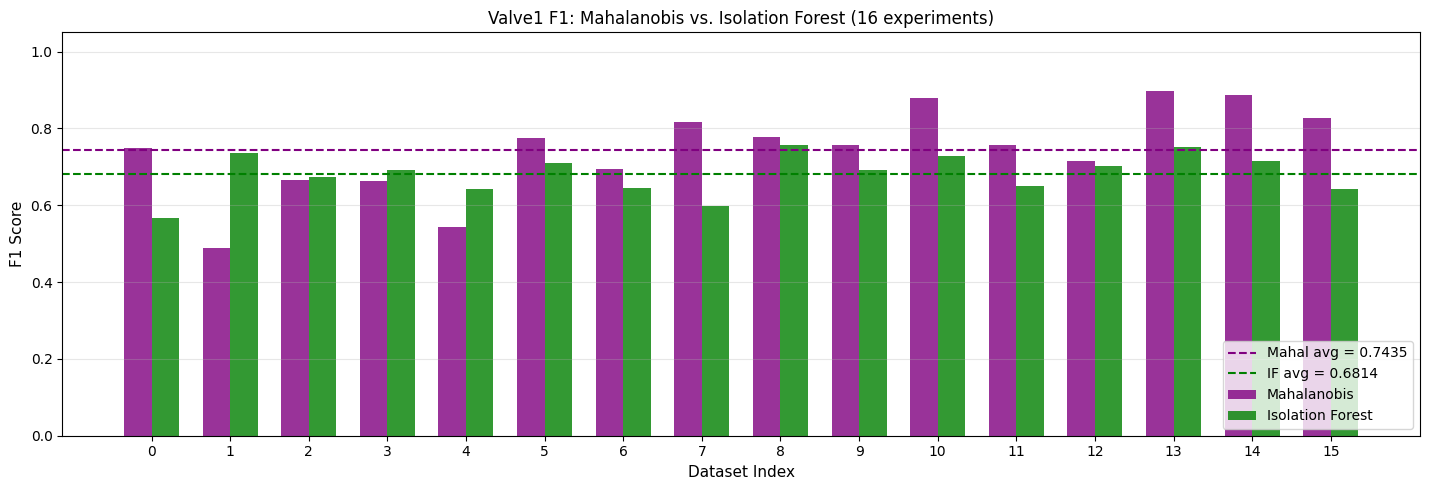

In [5]:
plot_f1_comparison(
    valve1_df,
    'Valve1 F1: Mahalanobis vs. Isolation Forest (16 experiments)'
)

---
## Valve 2 — 4 Experiments

Valve2 experiments use a different valve configuration. Same anomaly type as valve1 (controlled closures), but fewer experiments. Module 3 showed near-identical z-score and Mahalanobis performance here too.

In [6]:
valve2_df = run_benchmark('../data/SKAB/valve2', range(4))
print(f'Processed {len(valve2_df)} valve2 experiments')

avg_m  = valve2_df['m_f1'].mean()
avg_if = valve2_df['if_f1'].mean()
print(f'Avg F1 — Mahalanobis: {avg_m:.4f}  |  Isolation Forest: {avg_if:.4f}')

Processed 4 valve2 experiments
Avg F1 — Mahalanobis: 0.6955  |  Isolation Forest: 0.6872


In [7]:
display_results(
    valve2_df,
    'Valve2: Mahalanobis (M) vs. Isolation Forest (IF) — purple = Mahal wins, green = IF wins'
)

,Dataset,M F1,M Prec,M Rec,IF F1,IF Prec,IF Rec
0,0,0.5389,0.5503,0.5279,0.6840,0.5512,0.9010
1,1,0.6863,0.6430,0.7357,0.5394,0.4278,0.7297
2,2,0.6806,0.5595,0.8684,0.7246,0.5859,0.9494
3,3,0.8761,0.9032,0.8506,0.8009,0.7023,0.9316
4,1.500000,0.6955,0.6640,0.7457,0.6872,0.5668,0.8779


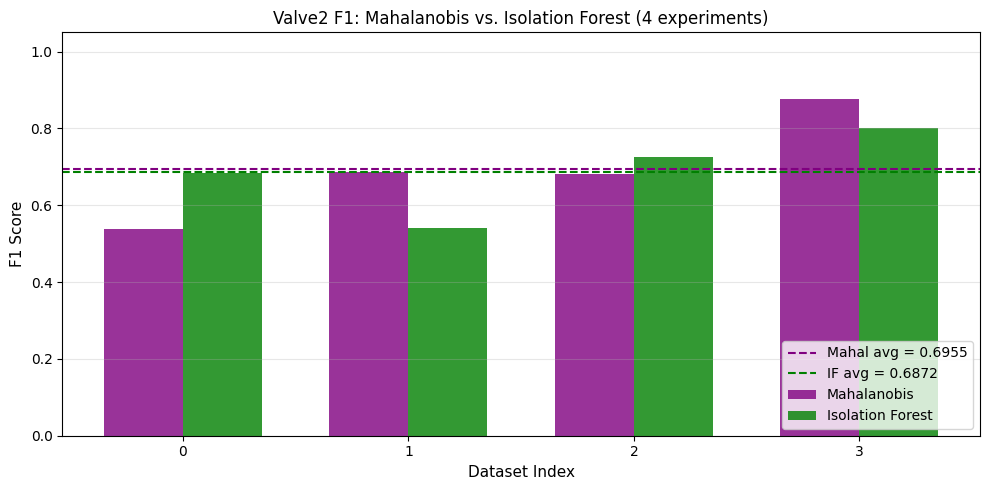

In [8]:
plot_f1_comparison(
    valve2_df,
    'Valve2 F1: Mahalanobis vs. Isolation Forest (4 experiments)'
)

---
## Other — 14 Experiments (Rotor Imbalance, Fluid Leaks, Cavitation)

The `other` dataset contains the more complex SKAB anomaly types:
- **Rotor imbalance**: increases vibration (Accelerometer1/2RMS) in a characteristic frequency pattern
- **Fluid leak**: gradually reduces flow and pressure
- **Cavitation**: produces distinctive vibration signatures at partial loads

These anomalies are more likely to be **multivariate and nonlinear** — potentially the regime where Isolation Forest has an advantage over Mahalanobis.

In [9]:
other_df = run_benchmark('../data/SKAB/other', range(1, 15))
print(f'Processed {len(other_df)} other experiments')

avg_m  = other_df['m_f1'].mean()
avg_if = other_df['if_f1'].mean()
print(f'Avg F1 — Mahalanobis: {avg_m:.4f}  |  Isolation Forest: {avg_if:.4f}')

Processed 14 other experiments
Avg F1 — Mahalanobis: 0.7104  |  Isolation Forest: 0.6634


In [10]:
display_results(
    other_df,
    'Other: Mahalanobis (M) vs. Isolation Forest (IF) — purple = Mahal wins, green = IF wins'
)

,Dataset,M F1,M Prec,M Rec,IF F1,IF Prec,IF Rec
0,1,0.8300,0.7094,1.0000,0.6330,0.4703,0.9681
1,2,0.1000,0.3026,0.0599,0.2891,0.2891,0.2891
2,3,0.6938,0.7018,0.6859,0.7517,0.6137,0.9698
3,4,0.9355,0.9971,0.8810,0.7366,0.6205,0.9063
4,5,0.8159,0.6891,1.0000,0.7421,0.5988,0.9756
5,6,0.8481,0.7363,1.0000,0.7419,0.5906,0.9975
6,7,0.8952,0.8122,0.9971,0.7284,0.5738,0.9971
7,8,0.6028,0.5756,0.6328,0.6516,0.5259,0.8561
8,9,0.8185,0.6951,0.9950,0.7091,0.5493,1.0000
9,10,0.8383,0.7608,0.9334,0.7716,0.6351,0.9829


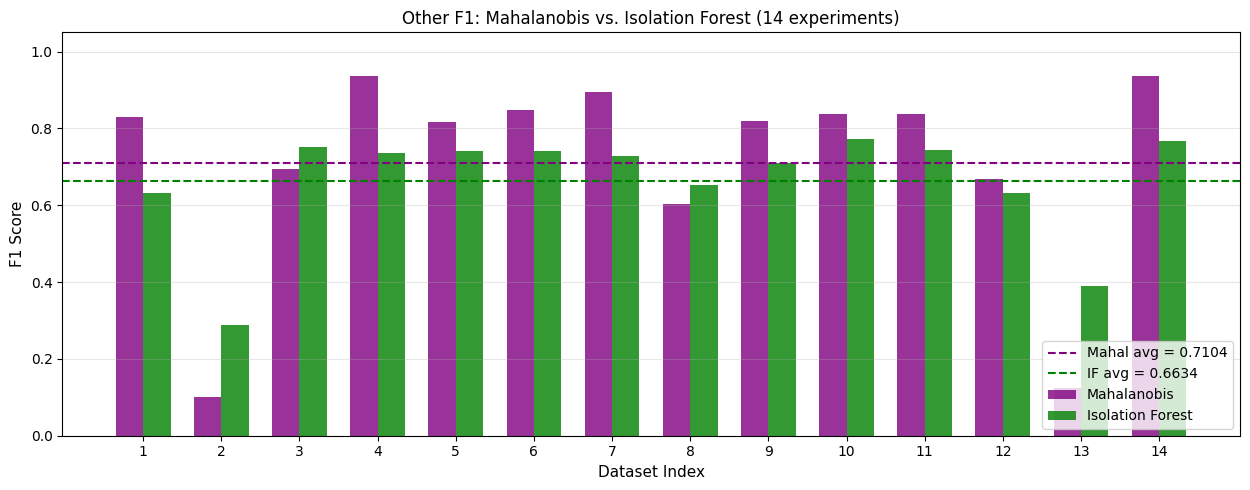

In [11]:
plot_f1_comparison(
    other_df,
    'Other F1: Mahalanobis vs. Isolation Forest (14 experiments)',
    x_labels=list(range(1, 15))
)

---
## Cross-Dataset Summary

In [12]:
summary = pd.DataFrame([
    {
        'Dataset': 'Valve1 (16 exp)',
        'M F1':  valve1_df['m_f1'].mean(),  'M Prec':  valve1_df['m_precision'].mean(),  'M Rec':  valve1_df['m_recall'].mean(),
        'IF F1': valve1_df['if_f1'].mean(), 'IF Prec': valve1_df['if_precision'].mean(), 'IF Rec': valve1_df['if_recall'].mean(),
    },
    {
        'Dataset': 'Valve2 (4 exp)',
        'M F1':  valve2_df['m_f1'].mean(),  'M Prec':  valve2_df['m_precision'].mean(),  'M Rec':  valve2_df['m_recall'].mean(),
        'IF F1': valve2_df['if_f1'].mean(), 'IF Prec': valve2_df['if_precision'].mean(), 'IF Rec': valve2_df['if_recall'].mean(),
    },
    {
        'Dataset': 'Other (14 exp)',
        'M F1':  other_df['m_f1'].mean(),  'M Prec':  other_df['m_precision'].mean(),  'M Rec':  other_df['m_recall'].mean(),
        'IF F1': other_df['if_f1'].mean(), 'IF Prec': other_df['if_precision'].mean(), 'IF Rec': other_df['if_recall'].mean(),
    },
])

# Add IF - M delta columns
summary['ΔF1 (IF−M)'] = summary['IF F1'] - summary['M F1']

print(summary.to_string(index=False, float_format='{:.4f}'.format))

        Dataset   M F1  M Prec  M Rec  IF F1  IF Prec  IF Rec  ΔF1 (IF−M)
Valve1 (16 exp) 0.7435  0.7254 0.8092 0.6814   0.5632  0.8712     -0.0620
 Valve2 (4 exp) 0.6955  0.6640 0.7457 0.6872   0.5668  0.8779     -0.0082
 Other (14 exp) 0.7104  0.7143 0.7863 0.6634   0.5379  0.8764     -0.0470


## Analysis & Observations

### Results (`contamination='auto'`)

| Dataset | Mahal F1 | Mahal P | Mahal R | IF F1 | IF P | IF R | ΔF1 (IF−M) |
|---------|----------|---------|---------|-------|------|------|------------|
| Valve1 (16 exp) | **0.7435** | **0.7254** | 0.8092 | 0.6814 | 0.5632 | **0.8712** | −0.0620 |
| Valve2 (4 exp)  | **0.6955** | **0.6640** | 0.7457 | 0.6872 | 0.5668 | **0.8779** | −0.0082 |
| Other  (14 exp) | **0.7104** | **0.7143** | 0.7863 | 0.6634 | 0.5379 | **0.8764** | −0.0470 |

Mahalanobis still wins on F1 across all three subsets, but the gaps have narrowed considerably vs. `contamination=0.05` (−0.14/−0.03/−0.05 before → −0.06/−0.01/−0.05 now). Valve2 is now essentially a tie.

### `contamination='auto'` swaps the tradeoff

With `contamination=0.05`, IF had low recall and adequate precision. With `'auto'`, the pattern reverses completely:

| Setting | Valve1 Precision | Valve1 Recall | Valve1 F1 |
|---------|-----------------|---------------|-----------|
| `contamination=0.05` | 0.6631 | 0.5849 | 0.6052 |
| `contamination='auto'` | 0.5632 | 0.8712 | 0.6814 |
| **Mahalanobis** | **0.7254** | 0.8092 | **0.7435** |

`'auto'` uses the score midpoint of −0.5 from the original Liu et al. paper as its threshold. Trained on 400 normal rows, this threshold turns out to be relatively permissive — it flags a large fraction of the test file, boosting recall (IF catches ~87% of anomalies vs Mahalanobis's ~81%) but generating substantially more false alarms (precision 0.56 vs Mahalanobis's 0.73).

Mahalanobis occupies the desirable middle ground: **higher precision than IF(auto) while matching or exceeding its recall on two of three datasets** — a better F1 outcome without favouring either side of the tradeoff.

### The threshold calibration problem persists

Both contamination settings expose the same underlying issue: IF's threshold requires an assumption about the anomaly rate or score distribution that doesn't transfer cleanly across datasets.

| Method | Threshold basis | Bias on SKAB |
|--------|----------------|--------------|
| Mahalanobis | Chi-squared 99.9% (statistical) | Well-calibrated: balanced P/R |
| IF (`contamination=0.05`) | 5th percentile of training scores | Too conservative: low recall |
| IF (`contamination='auto'`) | Score midpoint −0.5 (theoretical) | Too permissive: low precision |

The chi-squared critical value automatically adapts to the learned covariance structure of the training data — it tightens in low-variance regimes and loosens when sensors are more variable. The IF threshold, whether empirical or theoretical, has no equivalent self-calibration mechanism.

### Why Valve2 nearly ties with `'auto'`

Valve2 (−0.01 F1 gap) has the most compact anomaly type: sudden, high-intensity valve closures that are clearly distinct from normal operation. In this regime IF's overly permissive threshold matters less — the anomaly rows are so different from normal that even a low threshold correctly flags them with relatively few false alarms. When anomalies are ambiguous or gradual (as in some valve1 and other experiments), the extra false alarms from the permissive threshold accumulate and drag precision down.

### Did IF outperform on the complex `other` anomalies?

No — the `other` gap (−0.05 F1) remains larger than Valve2 despite containing the most complex anomaly types. The precision drop from `'auto'` is especially costly on these experiments: rotor imbalance and cavitation create gradual signature changes where the boundary between normal and anomalous is fuzzier, and a permissive threshold generates more borderline false alarms.

### SKAB vs. SWaT: the full picture

| Dataset | Winner | Margin (best IF setting) | Why |
|---------|--------|--------------------------|-----|
| SWaT    | **Mahalanobis** | +0.209 F1 | Stealthy covariance-violation attacks; explicit pairwise encoding is structurally matched to the anomaly type |
| SKAB valve1 | **Mahalanobis** | +0.062 F1 (`auto`) | `auto` overshoots precision; chi-squared threshold self-calibrates better |
| SKAB valve2 | **Mahalanobis** | +0.008 F1 (`auto`) | Effectively a tie |
| SKAB other  | **Mahalanobis** | +0.047 F1 (`auto`) | Gradual anomalies amplify the cost of IF's permissive threshold |

Mahalanobis wins every benchmark, but the margins on SKAB are narrow. The key structural advantage is threshold self-calibration from the chi-squared distribution — it doesn't require guessing an anomaly rate, and it produces balanced precision/recall without tuning.

### Practical takeaway

`contamination='auto'` is strictly better than any fixed value when the anomaly rate is unknown, and should be the default for IF in production. But even with `'auto'`, IF's threshold calibration is dataset-dependent in a way that Mahalanobis's is not. For use cases where a labelled validation set is available to tune contamination precisely, IF can close the gap further.